In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

In [5]:
df = pd.read_csv("../data/spam_dataset.csv", encoding="latin1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df=df.loc[:,~df.columns.str.startswith('Unnamed')]
df= df.dropna(axis=1, how="all")
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.columns 

Index(['v1', 'v2'], dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   str  
 1   v2      5572 non-null   str  
dtypes: str(2)
memory usage: 541.4 KB


In [9]:
df.isnull().sum()

v1    0
v2    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(403)

In [11]:
df=df.drop_duplicates()

In [12]:
df.shape[0]

5169

In [13]:
df['v2']=df['v2'].str.lower()
df.head()

,v1,v2
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


In [14]:
df['v2'] = df['v2'].str.replace(
    f'[{string.punctuation}]', '', regex=True
)

In [15]:
df['v2'] = df['v2'].str.replace(r'\d+', '', regex=True)

In [16]:
df['v2'] = df['v2'].str.strip()
df['v2'] = df['v2'].str.replace(r'\s+', ' ', regex=True)

In [22]:
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'message'})


In [23]:
df.head()

,label,message
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in a wkly comp to win fa cup final ...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(df['message'],df['label'],test_size=0.2,random_state=42, stratify=df['label'])

In [25]:
tfidf=TfidfVectorizer()
x_train=tfidf.fit_transform(x_train)
x_test=tfidf.transform(x_test)

In [26]:
encoder=LabelEncoder()
y=encoder.fit_transform (df['label'])

In [47]:
#naive_bayes
nb = MultinomialNB()
nb.fit(x_train, y_train)

y_pred_nb = nb.predict(x_test)

In [48]:
#logistic regression
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)

In [49]:
#svm
svm=LinearSVC()
svm.fit(x_train,y_train)
y_pred_svm=svm.predict(x_test)

In [50]:

print("Naive Bayes")
print(classification_report(y_test, y_pred_nb))

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

print("SVM")
print(classification_report(y_test, y_pred_svm))

Naive Bayes
              precision    recall  f1-score   support

         ham       0.94      1.00      0.97       889
        spam       1.00      0.61      0.76       145

    accuracy                           0.95      1034
   macro avg       0.97      0.81      0.87      1034
weighted avg       0.95      0.95      0.94      1034

Logistic Regression
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       889
        spam       0.97      0.75      0.85       145

    accuracy                           0.96      1034
   macro avg       0.97      0.87      0.91      1034
weighted avg       0.96      0.96      0.96      1034

SVM
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       889
        spam       0.97      0.90      0.94       145

    accuracy                           0.98      1034
   macro avg       0.98      0.95      0.96      1034
weighted avg       0.98      0.98     

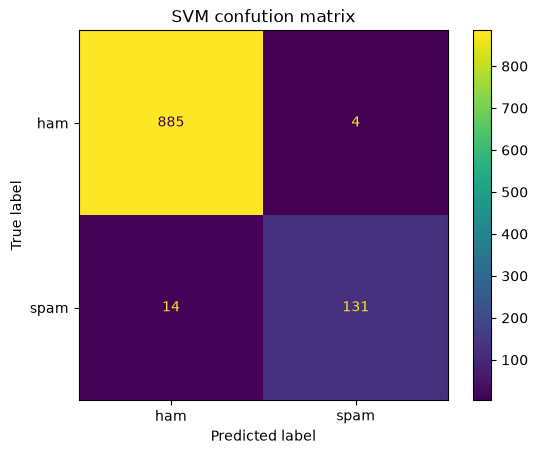

In [51]:
cm=confusion_matrix(y_test,y_pred_svm)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['ham','spam'])
disp.plot()
plt.title("SVM confution matrix")
plt.show()

In [52]:
print(classification_report(y_test,y_pred_svm))
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Best F1 Score:", grid.best_score_)

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       889
        spam       0.97      0.90      0.94       145

    accuracy                           0.98      1034
   macro avg       0.98      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034

Test accuracy: 0.971953578336557
Best F1 Score: 0.9779927448609431


In [54]:
# TUNING
param_grid={
     'C': [0.01, 0.1, 0.5, 1, 2, 5, 10, 50]
}
    

In [55]:
grid=GridSearchCV(svm,
                  param_grid,
                  cv=5,
                  scoring='accuracy',
                  n_jobs=-1)

In [56]:
grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding

In [57]:
print("Best Parameters:", grid.best_params_)
print("Best F1 Score:", grid.best_score_)
print("Test accuracy:", accuracy_score(y_test, y_pred))

Best Parameters: {'C': 2}
Best F1 Score: 0.9779927448609431
Test accuracy: 0.971953578336557


In [58]:
best_svm = grid.best_estimator_

y_pred = best_svm.predict(x_test)

In [59]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       889
        spam       0.96      0.90      0.93       145

    accuracy                           0.98      1034
   macro avg       0.97      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034

